In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
from scipy.interpolate import griddata
data=np.loadtxt('u_burger.txt', skiprows=8)


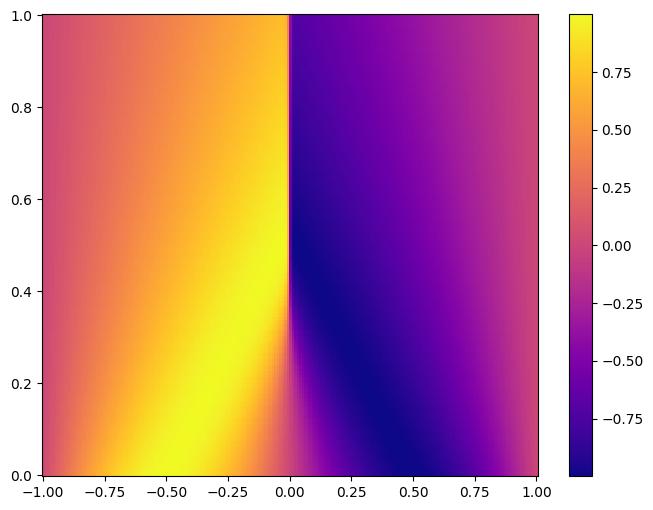

In [ ]:
x_data=data[:, 0]
y_data=data[:, 1]
u_data=data[:, 2]
min_X=np.min(x_data)
max_X=np.max(x_data)
min_Y=np.min(y_data)
max_Y=np.max(y_data)
min_U=np.min(u_data)
max_U=np.max(u_data)
x=np.linspace(min_X, max_X, 200)
y=np.linspace(min_Y, max_Y, 200)
u=np.linspace(min_U, max_U, 200)
grid_x, grid_y = np.meshgrid(x,y)
grid_z = griddata((x_data, y_data), u_data, (grid_x, grid_y), method='nearest')
plt.figure(figsize=(8, 6))
mesh = plt.pcolor(grid_x, grid_y, grid_z, cmap='plasma')
plt.colorbar()
plt.show()

In [ ]:
class PINNModel(nn.Module):
  def __init__(self,
              input_size = 1,
              nnodes = 30,
              output_size = 1,
              nhlayers = 20,
              activation=nn.Tanh(),
              ):
                super().__init__()
                self.activation = activation
                self.nhlayers = nhlayers
                self.nnodes = nnodes
                self.dense0 = nn.Linear(input_size, nnodes)
                self.hidden_layers = nn.ModuleList([
                nn.Linear(nnodes, nnodes) for _ in range(nhlayers)
                ])
                self.output_layer = nn.Linear(nnodes, 1)

def forward(self, x):
  if x.dtype == torch.float64:
    x = x.float()

  x = self.activation(self.dense0(x))

  for layer in self.hidden_layers:
    x = self.activation(layer(x))

  x=self.output_layer(x)
  x=self.activation(x)

  return x